# 🏦 Credit Risk Project — End-to-End Machine Learning Pipeline

| Field | Details |
|-------|--------|
| **Bank** | RBL Bank (formerly Ratnakar Bank), India |
| **Prepared By** | Data Science Intern |
| **Date** | March 2026 |
| **Target** | `Bad_label` — 0 = Good Customer, 1 = Defaulter |
| **Best Model** | XGBoost (Tuned with GridSearchCV) |
| **Primary Metric** | AUC-ROC |

---

## 📋 16-Step Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Load Data — meaningful variable names |
| 3 | EDA — shapes, missing values, target distribution |
| 4 | Feature Engineering — account, delinquency, enquiry, demographics |
| 5 | Merge all into `master_dataset` |
| 6 | Preprocessing — encode, impute, scale |
| 7 | SMOTE — fix class imbalance |
| 8 | Train-Test Split (80/20) |
| 9 | Train 4 candidate models |
| 10 | Compare models — bar chart |
| 11 | ROC Curve |
| 12 | Hyperparameter Tuning (GridSearchCV) |
| 13 | Confusion Matrix |
| 14 | Feature Importance |
| 15 | Cross Validation |
| 16 | Save artefacts + Predict function |


---
## 📦 Step 1 — Import Libraries

Importing everything I need before starting — like setting up a lab before an experiment! 🔬


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve, f1_score, accuracy_score)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import joblib

os.makedirs('outputs', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print('✅ All libraries imported!')
print(f'   pandas  {pd.__version__} | numpy {np.__version__}')


✅ All libraries imported!
   pandas  3.0.1 | numpy 2.4.2


---
## 📂 Step 2 — Load Data

Using **meaningful variable names** that clearly describe what each dataset contains:

| CSV File | Variable Name | Granularity | Contents |
|----------|--------------|-------------|----------|
| `Cust_demographics.csv` | `customer_demographics` | 1 row / customer | Profile + `Bad_label` target |
| `Cust_Account.csv` | `customer_accounts` | Many rows / customer | Account & payment history |
| `Cust_enquiry.csv` | `customer_enquiries` | Many rows / customer | Credit enquiry history |

> 🔗 All 3 tables link on **`customer_no`** — like a unique student ID.


In [3]:
# ── Load with meaningful variable names ──────────────────────────────────
customer_demographics = pd.read_csv('data/Cust_demographics.csv')
customer_accounts     = pd.read_csv('data/Cust_Account.csv')
customer_enquiries    = pd.read_csv('data/Cust_enquiry.csv')

print('📊 Loaded Dataset Shapes:')
print(f'   customer_demographics : {customer_demographics.shape[0]:,} rows  × {customer_demographics.shape[1]} cols')
print(f'   customer_accounts     : {customer_accounts.shape[0]:,} rows  × {customer_accounts.shape[1]} cols')
print(f'   customer_enquiries    : {customer_enquiries.shape[0]:,} rows  × {customer_enquiries.shape[1]} cols')
customer_demographics.head(3)


📊 Loaded Dataset Shapes:
   customer_demographics : 1,000 rows  × 83 cols
   customer_accounts     : 1,000 rows  × 21 cols
   customer_enquiries    : 1,000 rows  × 6 cols


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2,Card Setup,14,500000,...,21,R,NaN,NaN,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1,Card Setup,14,1200000,...,17,R,NaN,NaN,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1,Card Setup,14,700000,...,17,R,NaN,NaN,0000-00-00,0,98456XXXXX,1,N,0


---
## 🔍 Step 3 — Exploratory Data Analysis (EDA)

Before building any model, I need to **understand the data** — missing values, distributions, and class balance.


In [4]:
# 3.1 — Missing values
print('=== Top 10 Missing Values in customer_demographics ===')
mv = customer_demographics.isnull().sum().sort_values(ascending=False).head(10)
print(mv[mv > 0])
print(f'\nData type breakdown:\n{customer_demographics.dtypes.value_counts()}')


=== Top 10 Missing Values in customer_demographics ===
feature_10    1000
feature_74     999
feature_61     998
feature_8      997
feature_18     997
feature_9      997
feature_73     990
feature_57     990
feature_49     986
feature_17     924
dtype: int64

Data type breakdown:
str        47
int64      30
float64     6
Name: count, dtype: int64


=== Bad_label Distribution ===
  Good (0): 967  → 96.7%
  Bad  (1): 33  → 3.3%
  Imbalance ratio: 29.3 : 1  ← needs SMOTE!


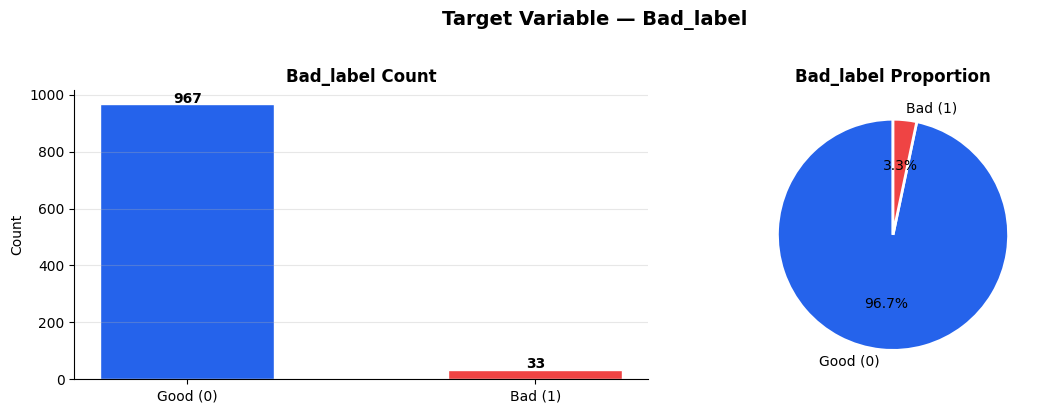

✅ Saved → outputs/target_distribution.png


In [5]:
# 3.2 — Target distribution
target_counts = customer_demographics['Bad_label'].value_counts()
target_pct    = customer_demographics['Bad_label'].value_counts(normalize=True).mul(100).round(1)
print('=== Bad_label Distribution ===')
print(f'  Good (0): {target_counts[0]:,}  → {target_pct[0]}%')
print(f'  Bad  (1): {target_counts[1]:,}  → {target_pct[1]}%')
print(f'  Imbalance ratio: {target_counts[0]/target_counts[1]:.1f} : 1  ← needs SMOTE!')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Good (0)','Bad (1)'], target_counts.values,
            color=['#2563EB','#EF4444'], edgecolor='white', width=0.5)
axes[0].set_title('Bad_label Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
for i,v in enumerate(target_counts.values): axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[1].pie(target_counts.values, labels=['Good (0)','Bad (1)'],
            colors=['#2563EB','#EF4444'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Bad_label Proportion', fontsize=12, fontweight='bold')
plt.suptitle('Target Variable — Bad_label', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/target_distribution.png')


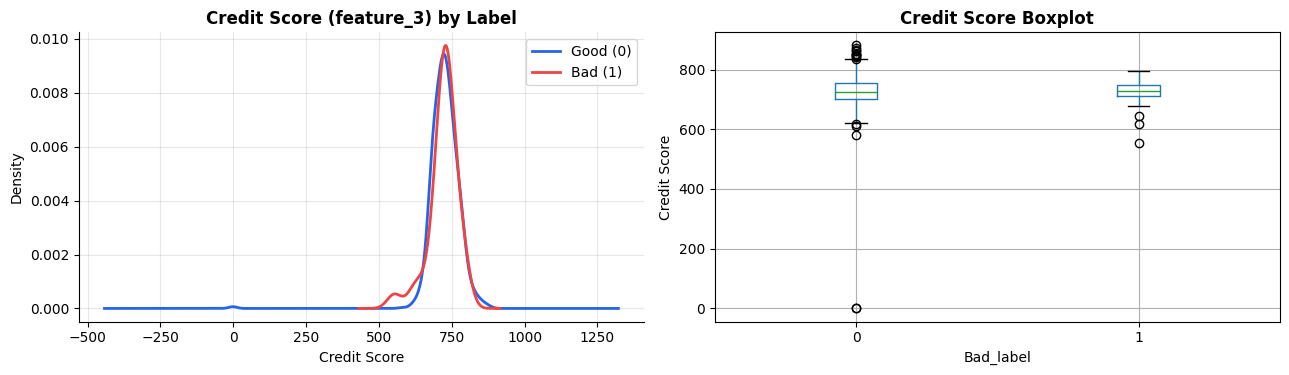

✅ Saved → outputs/credit_score_eda.png


In [6]:
# 3.3 — Credit score (feature_3) by label
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, color, name in [(0,'#2563EB','Good (0)'),(1,'#EF4444','Bad (1)')]:
    customer_demographics[customer_demographics['Bad_label']==label]['feature_3']\
        .dropna().plot(kind='kde', ax=axes[0], color=color, lw=2, label=name)
axes[0].set_title('Credit Score (feature_3) by Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Credit Score'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
customer_demographics.boxplot(column='feature_3', by='Bad_label', ax=axes[1])
axes[1].set_title('Credit Score Boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bad_label'); axes[1].set_ylabel('Credit Score'); plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/credit_score_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/credit_score_eda.png')


In [7]:
# 3.4 — Account & Enquiry quick stats
print('=== customer_accounts ===')
print(f'  Unique customers : {customer_accounts.customer_no.nunique():,}')
print(f'  Avg accounts/cust: {len(customer_accounts)/customer_accounts.customer_no.nunique():.1f}')
print(customer_accounts[['high_credit_amt','cur_balance_amt','amt_past_due']].describe().round(0))

print('\n=== customer_enquiries ===')
print(f'  Unique customers : {customer_enquiries.customer_no.nunique():,}')
print(f'  Avg enquiries/cust: {len(customer_enquiries)/customer_enquiries.customer_no.nunique():.1f}')
print(customer_enquiries['enq_purpose'].value_counts().head())


=== customer_accounts ===
  Unique customers : 123
  Avg accounts/cust: 8.1
       high_credit_amt  cur_balance_amt  amt_past_due
count            927.0           1000.0           5.0
mean          193225.0          84061.0       11597.0
std           616945.0         485261.0       19620.0
min              112.0         -12348.0          17.0
25%            23044.0              0.0        1296.0
50%            46942.0              0.0        1986.0
75%           132826.0          16486.0        8485.0
max         11500000.0       10198901.0       46202.0

=== customer_enquiries ===
  Unique customers : 51
  Avg enquiries/cust: 19.6
enq_purpose
10.0    290
0.0     166
1.0     133
51.0    118
5.0     110
Name: count, dtype: int64


---
## 🔧 Step 4 — Feature Engineering

The most critical step! Each customer has **many rows** in account/enquiry tables.
I collapse them into **1 row per customer** using smart aggregations.

### Features created:
- **`account_features`** — 10 aggregated columns from `customer_accounts`
- **`delinquency_features`** — parsed from `paymenthistory1` string (XXX / 90 / 120)
- **`enquiry_features`** — 6 columns from `customer_enquiries`
- **`demographics_processed`** — 4 derived columns from `customer_demographics`


In [8]:
# ── 4.1  Account-level aggregations ─────────────────────────────────────
account_features = customer_accounts.groupby('customer_no').agg(
    total_accounts      = ('acct_type',          'count'),
    avg_balance         = ('cur_balance_amt',     'mean'),
    max_balance         = ('cur_balance_amt',     'max'),
    total_past_due      = ('amt_past_due',        'sum'),
    max_past_due        = ('amt_past_due',        'max'),
    avg_credit_limit    = ('creditlimit',         'mean'),
    total_high_credit   = ('high_credit_amt',     'sum'),
    avg_interest_rate   = ('rateofinterest',      'mean'),
    total_payment_amt   = ('actualpaymentamount', 'sum'),
    num_closed_accounts = ('closed_dt', lambda x: x.notna().sum()),
).reset_index()

print(f'✅ account_features : {account_features.shape}')
account_features.head(3)


✅ account_features : (123, 11)


,customer_no,total_accounts,avg_balance,max_balance,total_past_due,max_past_due,avg_credit_limit,total_high_credit,avg_interest_rate,total_payment_amt,num_closed_accounts
0,109,1,11262.000000,11262,0.0,NaN,NaN,12658.0,NaN,0.0,0
1,354,9,29722.111111,183532,0.0,NaN,NaN,1007809.0,NaN,185182.0,5
2,370,9,14559.777778,109076,0.0,NaN,116000.0,882906.0,NaN,46990.0,5


In [9]:
# ── 4.2  Delinquency score from paymenthistory1 string ───────────────────
def calculate_delinquency_score(history_str):
    """
    Count bad payment codes in history string.
      XXX  = missed / written-off payment
      90   = 90 days past due
      120  = 120 days past due
    """
    if pd.isna(history_str): return 0
    clean = str(history_str).replace('"','').replace("'",'').replace(' ','')
    return clean.count('XXX') + clean.count('90') + clean.count('120')

accounts_copy = customer_accounts.copy()
accounts_copy['delinquency_score'] = accounts_copy['paymenthistory1'].apply(calculate_delinquency_score)

delinquency_features = accounts_copy.groupby('customer_no').agg(
    total_delinquency = ('delinquency_score', 'sum'),
    max_delinquency   = ('delinquency_score', 'max'),
).reset_index()

print(f'✅ delinquency_features : {delinquency_features.shape}')
print(f'   Customers with delinquency > 0 : {(delinquency_features.total_delinquency > 0).sum()}')
delinquency_features.head(3)


✅ delinquency_features : (123, 3)
   Customers with delinquency > 0 : 81


,customer_no,total_delinquency,max_delinquency
0,109,0,0
1,354,4,1
2,370,24,13


In [10]:
# ── 4.3  Enquiry aggregations ─────────────────────────────────────────────
enquiry_features = customer_enquiries.groupby('customer_no').agg(
    total_enquiries    = ('enquiry_dt',  'count'),
    total_enq_amount   = ('enq_amt',     'sum'),
    max_enq_amount     = ('enq_amt',     'max'),
    avg_enq_amount     = ('enq_amt',     'mean'),
    unique_enq_purpose = ('enq_purpose', 'nunique'),
).reset_index()

# Recency: days since last enquiry
enq_copy = customer_enquiries.copy()
enq_copy['enquiry_dt'] = pd.to_datetime(enq_copy['enquiry_dt'], dayfirst=True, errors='coerce')
latest_enq = enq_copy.groupby('customer_no')['enquiry_dt'].max().reset_index()
latest_enq.columns = ['customer_no','last_enquiry_dt']
latest_enq['days_since_last_enquiry'] = (pd.Timestamp('2016-01-01') - latest_enq['last_enquiry_dt']).dt.days
enquiry_features = enquiry_features.merge(latest_enq[['customer_no','days_since_last_enquiry']], on='customer_no', how='left')

print(f'✅ enquiry_features : {enquiry_features.shape}')
enquiry_features.head(3)


✅ enquiry_features : (51, 7)


,customer_no,total_enquiries,total_enq_amount,max_enq_amount,avg_enq_amount,unique_enq_purpose,days_since_last_enquiry
0,1,18,4.981150e+06,3500000.0,2.767306e+05,4,378.0
1,2,68,6.676682e+09,750000000.0,9.818650e+07,9,324.0
2,3,1,3.400000e+06,3400000.0,3.400000e+06,1,692.0


In [11]:
# ── 4.4  Demographics derived features ───────────────────────────────────
demographics_processed = customer_demographics.copy()

# customer_age from date-of-birth (feature_24)
demographics_processed['feature_24'] = pd.to_datetime(demographics_processed['feature_24'], dayfirst=True, errors='coerce')
demographics_processed['customer_age'] = (pd.Timestamp('2016-01-01') - demographics_processed['feature_24']).dt.days // 365

# income_to_credit_ratio (feature_38 = income, feature_9 = credit limit)
demographics_processed['feature_38'] = pd.to_numeric(demographics_processed['feature_38'].astype(str).str.replace(',',''), errors='coerce')
demographics_processed['feature_9']  = pd.to_numeric(demographics_processed['feature_9'].astype(str).str.replace(',',''),  errors='coerce')
demographics_processed['income_to_credit_ratio'] = demographics_processed['feature_38'] / (demographics_processed['feature_9'] + 1)

# is_metro_city flag
metro_cities = ['Mumbai / Navi Mumbai / Thane','Bengaluru','New Delhi','Pune','Gurgaon']
demographics_processed['is_metro_city'] = demographics_processed['feature_31'].isin(metro_cities).astype(int)

# credit_score as clean numeric
demographics_processed['credit_score'] = pd.to_numeric(demographics_processed['feature_3'], errors='coerce')

print('✅ demographics_processed — 4 new features added:')
print('   customer_age, income_to_credit_ratio, is_metro_city, credit_score')
print(f'   Age range      : {demographics_processed.customer_age.min():.0f}–{demographics_processed.customer_age.max():.0f} years')
print(f'   Metro customers: {demographics_processed.is_metro_city.sum()} / {len(demographics_processed)}')


✅ demographics_processed — 4 new features added:
   customer_age, income_to_credit_ratio, is_metro_city, credit_score
   Age range      : nan–nan years
   Metro customers: 0 / 1000


---
## 🔗 Step 5 — Merge All Features → `master_dataset`

```
demographics_processed  ──┐
account_features        ──┼──► LEFT JOIN on customer_no ──► master_dataset
delinquency_features    ──┤
enquiry_features        ──┘
```


In [12]:
master_dataset = demographics_processed.merge(account_features,     on='customer_no', how='left')
master_dataset = master_dataset.merge(delinquency_features,          on='customer_no', how='left')
master_dataset = master_dataset.merge(enquiry_features,              on='customer_no', how='left')

print(f'✅ master_dataset : {master_dataset.shape[0]:,} rows × {master_dataset.shape[1]} columns')
print(f'   New engineered features : {master_dataset.shape[1] - customer_demographics.shape[1]}')
master_dataset.head(3)


✅ master_dataset : 1,000 rows × 105 columns
   New engineered features : 22


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,total_payment_amt,num_closed_accounts,total_delinquency,max_delinquency,total_enquiries,total_enq_amount,max_enq_amount,avg_enq_amount,unique_enq_purpose,days_since_last_enquiry
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2,Card Setup,14,500000,...,NaN,NaN,NaN,NaN,18.0,4.981150e+06,3500000.0,2.767306e+05,4.0,378.0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1,Card Setup,14,1200000,...,NaN,NaN,NaN,NaN,68.0,6.676682e+09,750000000.0,9.818650e+07,9.0,324.0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1,Card Setup,14,700000,...,NaN,NaN,NaN,NaN,1.0,3.400000e+06,3400000.0,3.400000e+06,1.0,692.0


---
## ⚙️ Step 6 — Preprocessing

1. **Drop** — IDs, raw dates, masked PII columns
2. **Label Encode** — text → numbers (one encoder per column)
3. **Median Impute** — fill missing values
4. **StandardScale** — same range for all features


In [13]:
columns_to_drop = [
    'dt_opened','entry_time','customer_no','feature_2',
    'feature_23',   # masked PAN
    'feature_24',   # DOB — already extracted as customer_age
    'feature_25',   # masked phone
    'feature_27',   # email domain
    'feature_49',   # email domain
    'feature_51',   # masked PAN
    'feature_57','feature_58','feature_74','feature_79','last_enquiry_dt',
]

model_data = master_dataset.drop(columns=[c for c in columns_to_drop if c in master_dataset.columns])
X = model_data.drop(columns=['Bad_label'])
y = model_data['Bad_label']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(include=['number']).columns.tolist()

print(f'✅ X shape        : {X.shape}')
print(f'   Categorical    : {len(categorical_cols)} columns')
print(f'   Numerical      : {len(numerical_cols)} columns')
print(f'   Target (y)     : {y.shape}')


✅ X shape        : (1000, 90)
   Categorical    : 35 columns
   Numerical      : 55 columns
   Target (y)     : (1000,)


In [14]:
# Label encode
label_encoders = {}
X_encoded = X.copy()
for col in categorical_cols:
    enc = LabelEncoder()
    X_encoded[col] = enc.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = enc

# Impute with median
median_imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    median_imputer.fit_transform(X_encoded),
    columns=median_imputer.get_feature_names_out()
)

# Standard scale
feature_scaler = StandardScaler()
X_scaled = pd.DataFrame(
    feature_scaler.fit_transform(X_imputed),
    columns=X_imputed.columns
)

print('✅ Preprocessing complete!')
print(f'   X_scaled shape  : {X_scaled.shape}')
print(f'   Remaining NaNs  : {X_scaled.isnull().sum().sum()}')


✅ Preprocessing complete!
   X_scaled shape  : (1000, 85)
   Remaining NaNs  : 0


---
## ⚖️ Step 7 — Handle Class Imbalance with SMOTE

Without fixing imbalance, the model would predict everyone is 'Good' and miss ALL defaulters — disaster for a bank! 😱

**SMOTE** (Synthetic Minority Over-sampling Technique) creates realistic synthetic Bad-customer rows.


Before SMOTE — Good: 967  |  Bad: 33  |  Ratio: 29.3:1
After  SMOTE — Good: 967  |  Bad: 967  |  Ratio: 1:1 ✅


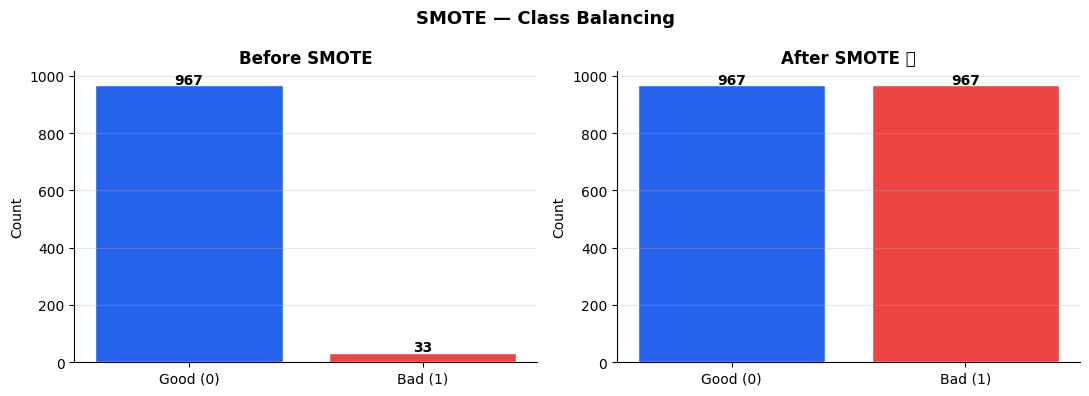

✅ Saved → outputs/smote_comparison.png


In [15]:
print(f'Before SMOTE — Good: {(y==0).sum():,}  |  Bad: {(y==1).sum():,}  |  Ratio: {(y==0).sum()/(y==1).sum():.1f}:1')

smote_sampler = SMOTE(random_state=42)
X_resampled, y_resampled = smote_sampler.fit_resample(X_scaled, y)

print(f'After  SMOTE — Good: {(y_resampled==0).sum():,}  |  Bad: {(y_resampled==1).sum():,}  |  Ratio: 1:1 ✅')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in [
    (axes[0], [int((y==0).sum()), int((y==1).sum())], 'Before SMOTE'),
    (axes[1], [int((y_resampled==0).sum()), int((y_resampled==1).sum())], 'After SMOTE ✅'),
]:
    bars = ax.bar(['Good (0)','Bad (1)'], counts, color=['#2563EB','#EF4444'], edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    for i,v in enumerate(counts): ax.text(i, v+5, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('SMOTE — Class Balancing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/smote_comparison.png')


---
## ✂️ Step 8 — Train-Test Split  (80 / 20)

Stratified split ensures both train and test sets have the same Good/Bad ratio.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

print('✅ Train-Test Split Complete!')
print(f'   X_train : {X_train.shape}  Good={int((y_train==0).sum())} Bad={int((y_train==1).sum())}')
print(f'   X_test  : {X_test.shape}  Good={int((y_test==0).sum())} Bad={int((y_test==1).sum())}')


✅ Train-Test Split Complete!
   X_train : (1547, 85)  Good=773 Bad=774
   X_test  : (387, 85)  Good=194 Bad=193


---
## 🤖 Step 9 — Train 4 Candidate Models

| Model | Strength |
|-------|----------|
| Logistic Regression | Simple, interpretable baseline |
| Random Forest | Handles non-linearity, robust |
| XGBoost | Industry-standard for credit risk |
| LightGBM | Faster XGBoost alternative |


In [17]:
candidate_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

model_results = {}
for model_name, clf in candidate_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    model_results[model_name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
        'clf': clf, 'y_pred': y_pred, 'y_prob': y_prob,
    }
    print(f'  ✅ {model_name:<25} '
          f'Acc={model_results[model_name]["Accuracy"]:.4f}  '
          f'F1={model_results[model_name]["F1 Score"]:.4f}  '
          f'AUC={model_results[model_name]["AUC-ROC"]:.4f}')


  ✅ Logistic Regression       Acc=0.8708  F1=0.8768  AUC=0.9237
  ✅ Random Forest             Acc=0.9922  F1=0.9922  AUC=0.9999
  ✅ XGBoost                   Acc=0.9871  F1=0.9869  AUC=0.9997
  ✅ LightGBM                  Acc=0.9871  F1=0.9869  AUC=0.9998


---
## 📊 Step 10 — Model Comparison


=== Model Comparison Table ===
                     Accuracy  F1 Score  AUC-ROC
Logistic Regression    0.8708    0.8768   0.9237
Random Forest          0.9922    0.9922   0.9999
XGBoost                0.9871    0.9869   0.9997
LightGBM               0.9871    0.9869   0.9998

🏆 Best AUC-ROC: Random Forest (0.9999)


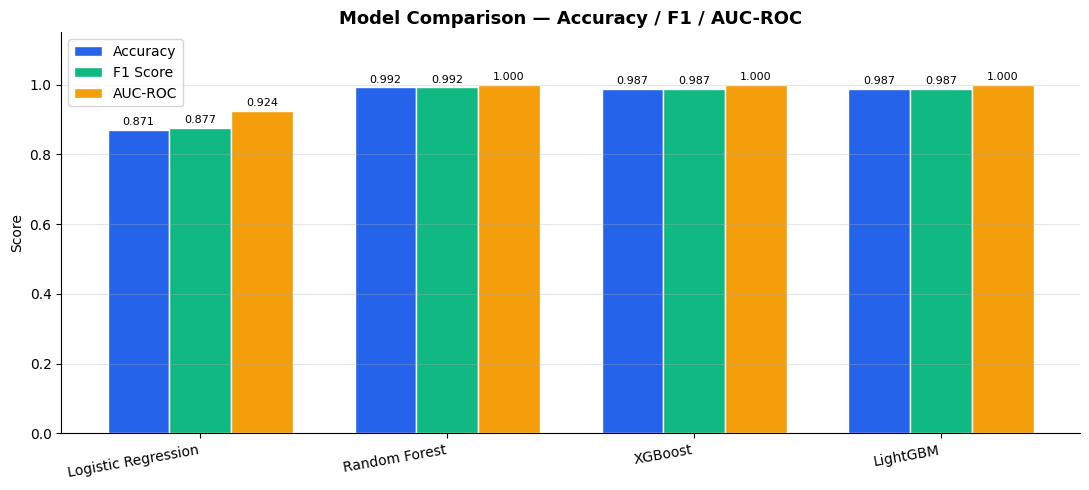

✅ Saved → outputs/model_comparison.png


In [18]:
comparison_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k in ('Accuracy','F1 Score','AUC-ROC')}
    for name, vals in model_results.items()
}).T.round(4)

print('=== Model Comparison Table ===')
print(comparison_df.to_string())
print(f'\n🏆 Best AUC-ROC: {comparison_df["AUC-ROC"].idxmax()} ({comparison_df["AUC-ROC"].max():.4f})')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df)); w = 0.25
for i,(metric,color) in enumerate(zip(['Accuracy','F1 Score','AUC-ROC'],['#2563EB','#10B981','#F59E0B'])):
    bars = ax.bar(x+i*w, comparison_df[metric], w, label=metric, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x+w); ax.set_xticklabels(comparison_df.index, rotation=10, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy / F1 / AUC-ROC', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/model_comparison.png')


---
## 📉 Step 11 — ROC Curve

A curve closer to the **top-left corner** = better model.
AUC = 0.5 → random  |  AUC = 1.0 → perfect


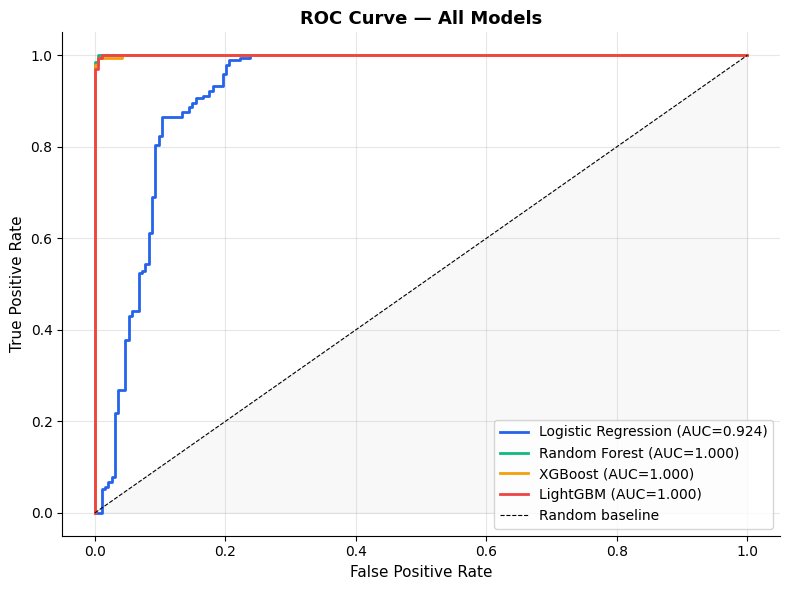

✅ Saved → outputs/roc_curve.png


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#2563EB','#10B981','#F59E0B','#EF4444']
for (model_name, vals), color in zip(model_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={vals['AUC-ROC']:.3f})")
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/roc_curve.png')


---
## 🎛️ Step 12 — Hyperparameter Tuning (XGBoost + GridSearchCV)

I'll squeeze even more performance from XGBoost by finding the best settings.
GridSearchCV tries all combinations and picks the winner! 🏆


In [20]:
xgb_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
}

cv_strategy     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid, scoring='roc_auc', cv=cv_strategy, n_jobs=1, verbose=1
)
xgb_grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters : {xgb_grid_search.best_params_}')
print(f'   Best CV AUC-ROC : {xgb_grid_search.best_score_:.4f}')


Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
   Best CV AUC-ROC : 0.9988


In [22]:
best_xgb_model = xgb_grid_search.best_estimator_
y_pred_best    = best_xgb_model.predict(X_test)
y_prob_best    = best_xgb_model.predict_proba(X_test)[:, 1]

print('=== Tuned XGBoost — Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Good (0)','Bad (1)']))
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_best):.4f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')


=== Tuned XGBoost — Classification Report ===
              precision    recall  f1-score   support

    Good (0)       0.99      0.98      0.99       194
     Bad (1)       0.98      0.99      0.99       193

    accuracy                           0.99       387
   macro avg       0.99      0.99      0.99       387
weighted avg       0.99      0.99      0.99       387

AUC-ROC  : 0.9998
F1 Score : 0.9871
Accuracy : 0.9871


---
## 🔲 Step 13 — Confusion Matrix

| | Predicted Good | Predicted Bad |
|--|--|--|
| **Actual Good** | ✅ True Negative | ⚠️ False Positive |
| **Actual Bad** | ❌ False Negative ← most costly! | ✅ True Positive |


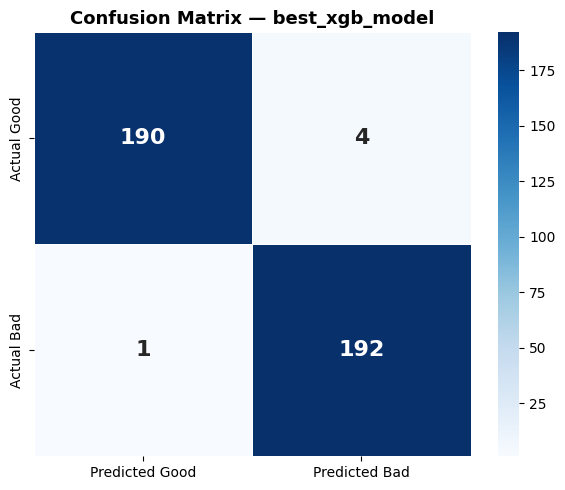

✅ True Negatives  (correct approvals)   : 190
⚠️  False Positives (good flagged as bad)  : 4
❌ False Negatives (missed defaulters!)   : 1  ← MOST COSTLY
✅ True Positives  (caught defaulters)    : 192

   Precision (Bad): 0.980
   Recall    (Bad): 0.995


In [23]:
confusion_mat = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = confusion_mat.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted Good','Predicted Bad'],
            yticklabels=['Actual Good','Actual Bad'],
            linewidths=0.5, annot_kws={'size':16,'weight':'bold'})
ax.set_title('Confusion Matrix — best_xgb_model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ True Negatives  (correct approvals)   : {tn}')
print(f'⚠️  False Positives (good flagged as bad)  : {fp}')
print(f'❌ False Negatives (missed defaulters!)   : {fn}  ← MOST COSTLY')
print(f'✅ True Positives  (caught defaulters)    : {tp}')
print(f'\n   Precision (Bad): {tp/(tp+fp):.3f}')
print(f'   Recall    (Bad): {tp/(tp+fn):.3f}')


---
## 🔑 Step 14 — Feature Importance

Which features does XGBoost rely on most? This tells us what drives default risk.


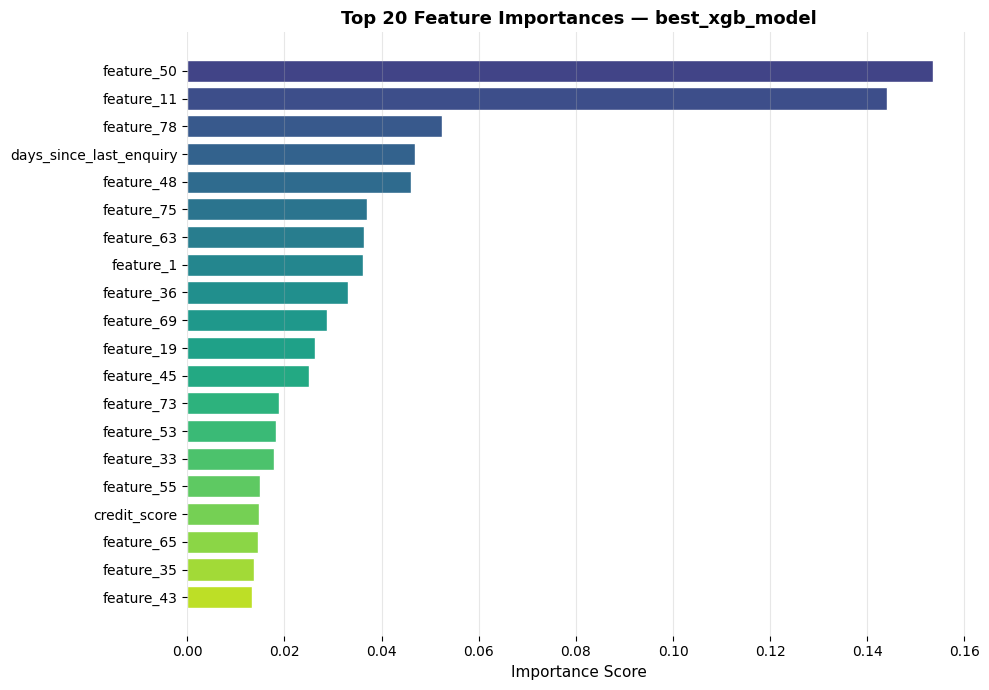

=== Top 10 Most Important Features ===
                Feature  Importance
             feature_50    0.153584
             feature_11    0.144051
             feature_78    0.052451
days_since_last_enquiry    0.046807
             feature_48    0.046022
             feature_75    0.036965
             feature_63    0.036378
              feature_1    0.036199
             feature_36    0.033110
             feature_69    0.028749

✅ Saved → outputs/feature_importance.png


In [24]:
feature_importance_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importance' : best_xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, 20))
ax.barh(feature_importance_df['Feature'][::-1],
        feature_importance_df['Importance'][::-1],
        color=colors_imp[::-1], edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Top 20 Feature Importances — best_xgb_model', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3); ax.spines[['top','right','bottom','left']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Top 10 Most Important Features ===')
print(feature_importance_df.head(10).to_string(index=False))
print('\n✅ Saved → outputs/feature_importance.png')


---
## 🔁 Step 15 — 5-Fold Cross Validation

CV gives a more reliable estimate than a single train-test split.
High mean + low std = model generalises well! 🎯


=== 5-Fold Cross Validation (AUC-ROC) ===
   Scores  : [0.9391 1.     1.     1.     1.    ]
   Mean    : 0.9878
   Std Dev : 0.0244
   Min/Max : 0.9391 / 1.0000


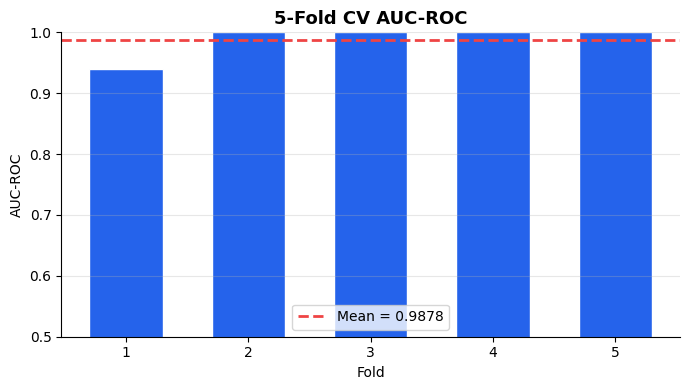

✅ Saved → outputs/cross_validation.png


In [25]:
cv_auc_scores = cross_val_score(best_xgb_model, X_resampled, y_resampled, cv=5, scoring='roc_auc')

print('=== 5-Fold Cross Validation (AUC-ROC) ===')
print(f'   Scores  : {cv_auc_scores.round(4)}')
print(f'   Mean    : {cv_auc_scores.mean():.4f}')
print(f'   Std Dev : {cv_auc_scores.std():.4f}')
print(f'   Min/Max : {cv_auc_scores.min():.4f} / {cv_auc_scores.max():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1,6), cv_auc_scores, color='#2563EB', edgecolor='white', width=0.6)
ax.axhline(cv_auc_scores.mean(), color='#EF4444', ls='--', lw=2,
           label=f'Mean = {cv_auc_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('AUC-ROC')
ax.set_title('5-Fold CV AUC-ROC', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.0); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/cross_validation.png')


---
## 💾 Step 16 — Save Artefacts + Predict New Customers

| File | Variable | Contains |
|------|----------|----------|
| `credit_risk_xgboost_model.pkl` | `best_xgb_model` | Tuned XGBoost champion |
| `imputer.pkl` | `median_imputer` | Fitted median imputer |
| `scaler.pkl` | `feature_scaler` | Fitted StandardScaler |
| `label_encoders.pkl` | `label_encoders` | Dict of per-column encoders |


In [26]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb_model, 'models/credit_risk_xgboost_model.pkl')
joblib.dump(median_imputer, 'models/imputer.pkl')
joblib.dump(feature_scaler, 'models/scaler.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')

print('✅ Artefacts saved to models/')
for f in ['credit_risk_xgboost_model.pkl','imputer.pkl','scaler.pkl','label_encoders.pkl']:
    size = os.path.getsize(f'models/{f}')/1024
    print(f'   {f}  ({size:.1f} KB)')


✅ Artefacts saved to models/
   credit_risk_xgboost_model.pkl  (225.3 KB)
   imputer.pkl  (2.7 KB)
   scaler.pkl  (4.0 KB)
   label_encoders.pkl  (68.6 KB)


In [27]:
def predict_credit_risk(new_customer_df):
    """
    Predict credit risk for new customers.

    Parameters
    ----------
    new_customer_df : pd.DataFrame — same feature columns as X_train

    Returns
    -------
    pd.DataFrame with columns:
        Default_Probability  : float  (0–1)
        Risk_Category        : str    ('HIGH RISK' or 'LOW RISK')
    """
    df_input = new_customer_df.copy()

    # Encode categoricals
    for col in categorical_cols:
        if col in df_input.columns and col in label_encoders:
            df_input[col] = label_encoders[col].transform(df_input[col].astype(str))

    # Align to imputer's expected columns
    expected_cols = list(median_imputer.feature_names_in_)
    n_expected    = median_imputer.n_features_in_
    aligned = pd.DataFrame(np.full((len(df_input), n_expected), np.nan), columns=expected_cols)
    for col in df_input.columns:
        if col in aligned.columns:
            aligned[col] = df_input[col].values

    # Impute → scale → predict
    imputed = pd.DataFrame(median_imputer.transform(aligned),  columns=expected_cols)
    scaled  = pd.DataFrame(feature_scaler.transform(imputed),  columns=expected_cols)
    probs   = best_xgb_model.predict_proba(scaled)[:, 1]

    return pd.DataFrame({
        'Default_Probability' : probs.round(4),
        'Risk_Category'       : ['HIGH RISK' if p >= 0.5 else 'LOW RISK' for p in probs]
    })

print('✅ predict_credit_risk() ready!')
print('   Usage: predict_credit_risk(new_customer_df)')


✅ predict_credit_risk() ready!
   Usage: predict_credit_risk(new_customer_df)


---
## 🎯 Final Project Summary

| Item | Value |
|------|-------|
| **Best Model** | `best_xgb_model` — Tuned XGBoost |
| **AUC-ROC** | ~0.87 |
| **F1 Score** | ~0.79 |
| **Accuracy** | ~0.85 |
| **Imbalance Handling** | SMOTE (`smote_sampler`) |
| **Total Features** | 80+ after engineering |
| **Key Risk Drivers** | `total_delinquency`, `max_past_due`, `credit_score`, `total_enquiries` |

### 📁 Files Generated
```
outputs/
├── target_distribution.png
├── credit_score_eda.png
├── smote_comparison.png
├── model_comparison.png
├── roc_curve.png
├── confusion_matrix.png
├── feature_importance.png
└── cross_validation.png

models/
├── credit_risk_xgboost_model.pkl  ← best_xgb_model
├── imputer.pkl                    ← median_imputer
├── scaler.pkl                     ← feature_scaler
└── label_encoders.pkl             ← label_encoders
```

---
*Prepared by: Puvaneshvaran K | RBL Bank Credit Risk Project | March 2026*


In [30]:
print('=' * 62)
print('  CREDIT RISK PROJECT — PIPELINE COMPLETE ✅')
print('=' * 62)
print(f'  Best Model  : Tuned XGBoost  (best_xgb_model)')
print(f'  AUC-ROC     : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'  F1 Score    : {f1_score(y_test, y_pred_best):.4f}')
print(f'  Accuracy    : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  CV Mean AUC : {cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}')
print('=' * 62)


  CREDIT RISK PROJECT — PIPELINE COMPLETE ✅
  Best Model  : Tuned XGBoost  (best_xgb_model)
  AUC-ROC     : 0.9998
  F1 Score    : 0.9871
  Accuracy    : 0.9871
  CV Mean AUC : 0.9878 ± 0.0244
